In [1]:
!pip install -q -U transformers accelerate datasets

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 43.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 35.5 MB/s eta 0:00:00
device: cuda


In [3]:
MODEL_NAME = "gpt2-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

for p in model.parameters():
    p.requires_grad_(False)  # frozen model

print(model.config.n_layer, "layers,", model.config.n_embd, "hidden dim")

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

36 layers, 1280 hidden dim


In [6]:
ln_f = model.transformer.ln_f
lm_head = model.lm_head

In [7]:
from datasets import load_dataset

raw = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
text = "\n\n".join(t for t in raw["text"] if t.strip())

BLOCK_SIZE = 64
all_ids = tokenizer(text, return_tensors="pt")["input_ids"][0]
n_blocks = len(all_ids) // BLOCK_SIZE
all_ids = all_ids[: n_blocks * BLOCK_SIZE].reshape(n_blocks, BLOCK_SIZE)

dataset = TensorDataset(all_ids)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
print(n_blocks, "training blocks of", BLOCK_SIZE, "tokens each")

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2415650 > 1024). Running this sequence through the model will result in indexing errors


37744 training blocks of 64 tokens each


In [8]:
class TunedLensTranslators(nn.Module):
    def __init__(self, n_layer, hidden_dim):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layer)])
        for layer in self.layers:
            layer.weight.data.copy_(torch.eye(hidden_dim))
            layer.bias.data.zero_()


translators = TunedLensTranslators(model.config.n_layer, model.config.n_embd).to(device)
print(sum(p.numel() for p in translators.parameters()), "trainable parameters")

59028480 trainable parameters


In [9]:
sample_prompt = "The Eiffel Tower is located in the city of"
sample_inputs = tokenizer(sample_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    sample_outputs = model(**sample_inputs, output_hidden_states=True)

check_layer = 3
h = sample_outputs.hidden_states[check_layer][0, -1, :]

plain_logits = lm_head(ln_f(h))
translated_logits = lm_head(ln_f(translators.layers[check_layer](h)))

diff = (plain_logits - translated_logits).abs().max().item()
print("identity-init check, max diff:", diff)
assert diff < 1e-4, "Untrained translator doesn't match plain logit lens -- check identity init."

identity-init check, max diff: 0.0


In [10]:
def translator_loss(translator, h, target_probs, ln_f, lm_head):
    """KL(target_probs || translated distribution) -- how far the lens's guess is
    from what the model would actually say, not from the ground-truth next token.
    """
    translated_logits = lm_head(ln_f(translator(h)))
    translated_log_probs = F.log_softmax(translated_logits.float(), dim=-1)
    return F.kl_div(translated_log_probs, target_probs, reduction="batchmean")

step 0: total loss 137.3122
step 50: total loss 48.5135
step 100: total loss 44.3541
step 150: total loss 43.6761
step 200: total loss 45.8566
step 250: total loss 42.8841


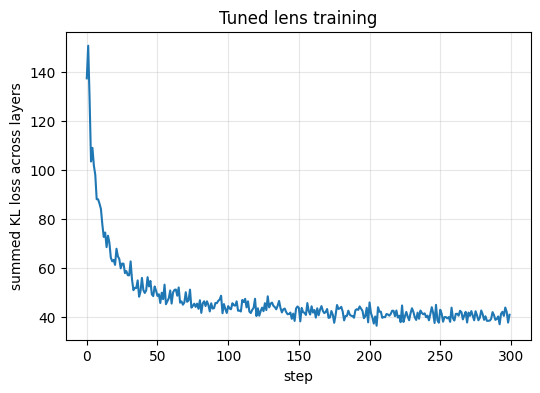

In [11]:
optimizer = torch.optim.Adam(translators.parameters(), lr=1e-3)
NUM_STEPS = 300

loss_curve = []
step = 0
for (input_ids,) in dataloader:
    if step >= NUM_STEPS:
        break
    input_ids = input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, output_hidden_states=True)
        target_probs = F.softmax(outputs.logits.float(), dim=-1).reshape(-1, outputs.logits.shape[-1])

    optimizer.zero_grad()
    total_loss = 0.0
    for i in range(model.config.n_layer):
        h = outputs.hidden_states[i].reshape(-1, outputs.hidden_states[i].shape[-1])
        total_loss = total_loss + translator_loss(translators.layers[i], h, target_probs, ln_f, lm_head)
    total_loss.backward()
    optimizer.step()

    loss_curve.append(total_loss.item())
    if step % 50 == 0:
        print(f"step {step}: total loss {total_loss.item():.4f}")
    step += 1

plt.figure(figsize=(6, 4))
plt.plot(loss_curve)
plt.xlabel("step")
plt.ylabel("summed KL loss across layers")
plt.title("Tuned lens training")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/tuned_lens_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()